In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [5]:
from contra_seq_dataset import get_dataset_array, get_anc_map
import copy

test_or_train = 'test'

home = '/home/kat/Repos/SALSA/'
anc_path = f'{home}data/model_ready/01/{test_or_train}/anchor_smiles.csv'
aug_path = f'{home}data/model_ready/01/{test_or_train}/augmented_smiles.csv'

ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)
df = copy.deepcopy(ds_arr)
df_sort = df.sort_values(by='smiles', key=lambda x: x.str.len())
# display(df_sort)

In [12]:
df_ancs = df_sort[df_sort.atype=='Anc'] #[:70]
df_ancs

,smiles,atype,anc_idx
1909,COCOCCC#CCO,Anc,1909
449,CSCCCCCCN=C=S,Anc,449
314,Nc1cccc2nnccc12,Anc,314
1158,OCC1Cc2ccccc2CN1,Anc,1158
1851,Cn1cnc2ncnc-2c1N,Anc,1851
...,...,...,...
204,O=C(Nc1ccc([N+](=O)[O-])cc1)C1OC(CNCc2ccc(Cl)c...,Anc,204
1717,CC(C)CNc1nc(=O)c2c([nH]1)n(C1OC(COP(=O)([O-])O...,Anc,1717
655,O=C1ON=C(c2ccc(Cl)c([N+](=O)[O-])c2)C1=Cc1cccc...,Anc,655
1826,O=[N+]([O-])c1ccc(S(=O)(=O)N2CC#Cc3ccccc3C#CCC...,Anc,1826


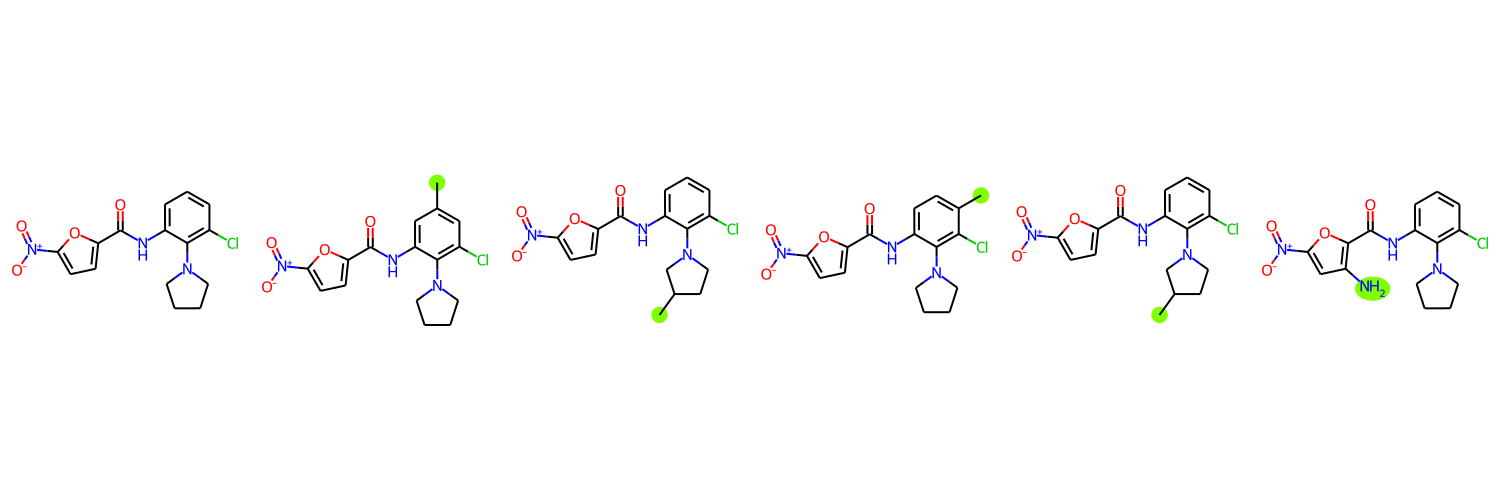

In [20]:
from rdkit.Chem import AllChem
from rdkit import Chem, Geometry
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True)
# IPythonConsole.drawOptions.minFontSize=20
from matplotlib.colors import ColorConverter

def get_highlighted_atoms(anc_mol, aug_mol):
    mcs = rdFMCS.FindMCS([anc_mol,aug_mol])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    match = aug_mol.GetSubstructMatch(mcs_mol)
    highlight_atoms = []
    for atom in aug_mol.GetAtoms():
        if atom.GetIdx() not in match:
            highlight_atoms.append(atom.GetIdx())
    return highlight_atoms

from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
from io import BytesIO

# def DrawMolsZoomed(mols, subImgSize=(250, 250)):

#     fullSize = (molsPerRow * subImgSize[0], subImgSize[1])
#     full_image = Image.new('RGBA', fullSize )

#     for i, mol in enumerate(mols):
#         if i==0:
#             offset = ( column*subImgSize[0], 0 )
            
#         if mol.GetNumConformers() == 0:
#             AllChem.Compute2DCoords(mol)
#         column = ii % molsPerRow
#         row = ii // molsPerRow
#         offset = ( column*subImgSize[0], row * subImgSize[1] )
#         d2d = rdMolDraw2D.MolDraw2DCairo(subImgSize[0], subImgSize[1])
#         d2d.DrawMolecule(mol)
#         d2d.FinishDrawing()
#         sub = Image.open(BytesIO(d2d.GetDrawingText()))
#         full_image.paste(sub,box=offset)
#     return full_image


c = ColorConverter().to_rgb('chartreuse') # mediumspringgreen cyan chartreuse

for idx in df_ancs.anc_idx.values:
    if idx!=11:
        continue
    
    draw = True
    smis = df[df.anc_idx==idx]
    anc_smi = smis[smis.atype=='Anc'].smiles.values[0]
#     print(idx, anc_smi)
    aug_smis = smis[smis.atype=='Aug'].smiles.values
    
    anc_mol = Chem.MolFromSmiles(anc_smi)
    aug_mols = [Chem.MolFromSmiles(sm) for sm in aug_smis] 
    all_mols = [anc_mol] + aug_mols
    
    matched_coords = [x.GetSubstructMatch(anc_mol) for x in all_mols]
    
    AllChem.Compute2DCoords(anc_mol)
    coords = [anc_mol.GetConformer().GetAtomPosition(x) for x in matched_coords[0]]
    coords2D = [Geometry.Point2D(pt.x,pt.y) for pt in coords]
    
    highlights = []
    colors = []
    
    for i,mol in enumerate(all_mols):
                
        # align skeletons
        try:
            coordDict={}
            for j,coord in enumerate(coords2D):
                coordDict[matched_coords[i][j]] = coord
            AllChem.Compute2DCoords(mol,coordMap=coordDict)

            # get highlights for aug mols
            if i == 0:
                highlight = False
                atom_col = {}
            else:
                highlight = get_highlighted_atoms(anc_mol, mol)
                atom_col = {highlight[0]: c}

            colors.append(atom_col)
            highlights.append(highlight)
            
        except:
            draw = False
    if draw:
        img = Draw.MolsToGridImage(all_mols, molsPerRow=6, highlightAtomLists=highlights,
                               highlightAtomColors=colors, subImgSize=(250,500)) #(250, 185)) # 200, 150
        display(img)
#     break